<a href="https://colab.research.google.com/github/arsingla786/MLFromScratch/blob/main/Regularization_ANN(decrease_overfitting).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [4]:
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.optimizers import Adam

In [5]:
X,y = make_moons(100,noise=0.25,random_state=2)

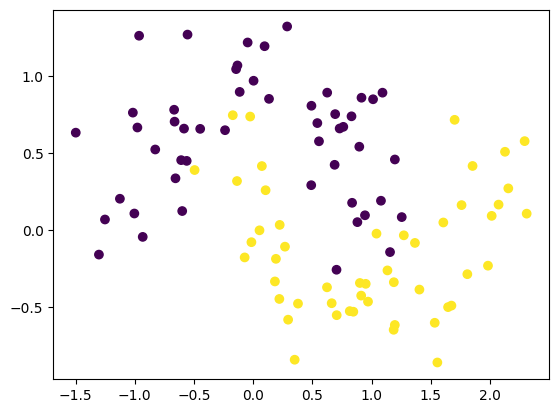

In [6]:
plt.scatter(X[:,0],X[:,1],c=y)

In [7]:
model_1 = Sequential()

model_1.add(Dense(128,activation='relu',input_dim=2))
model_1.add(Dense(128,activation='relu'))
model_1.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model_1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [9]:
history1 =  model_1.fit(X,y,epochs=2000,validation_split=0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


(-2.3, 3.308379838205417)

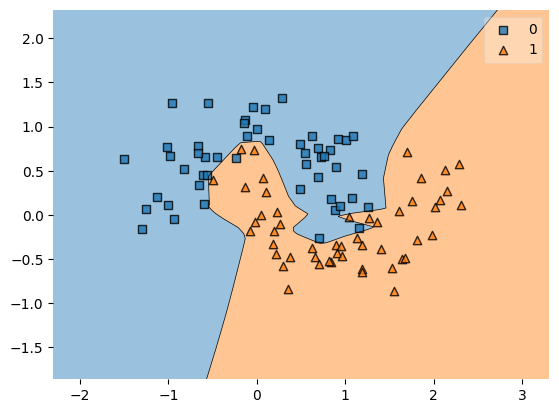

In [10]:
plot_decision_regions(X,y,model_1)
plt.xlim(-2.3)

#overfit wont work fine on

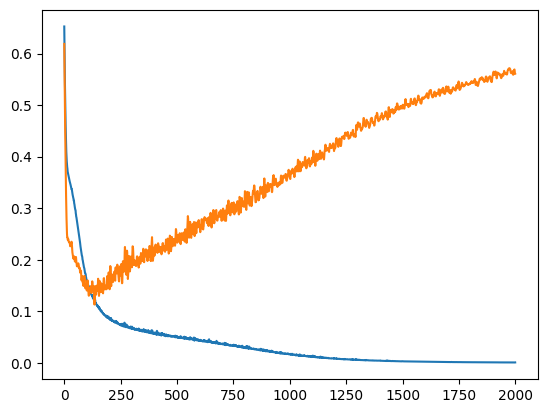

In [11]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

##same  model with Dropout

In [12]:
model_2 = Sequential()

model_2.add(Dense(128,activation='relu',input_dim=2))
model_2.add(Dropout(0.2))
model_2.add(Dense(128,activation='relu'))
model_2.add(Dropout(0.2))
model_2.add(Dense(1,activation='sigmoid'))

In [13]:
model_2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [14]:
history2 = model_2.fit(X,y,epochs=2000,validation_split=0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


(-2.3, 3.308379838205417)

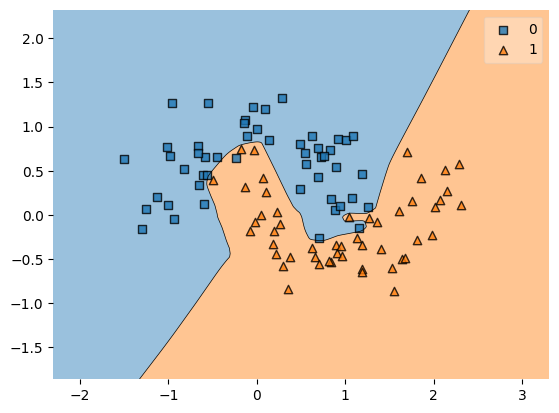

In [15]:
plot_decision_regions(X,y,model_2)
plt.xlim(-2.3)

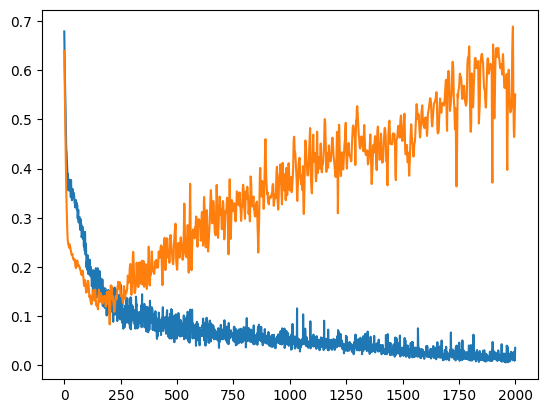

In [16]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

##same model with regularization

In [17]:
model_3 = Sequential()

model_3.add(Dense(128,input_dim=2,activation='relu',kernel_regularizer = tensorflow.keras.regularizers.l2(0.05)))
model_3.add(Dense(128,input_dim=2,activation='relu',kernel_regularizer = tensorflow.keras.regularizers.l2(0.03)))
model_3.add(Dense(1,activation='sigmoid'))

In [18]:
model_3.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [19]:
history3 = model_3.fit(X,y,epochs=2000,validation_split=0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


(-2.3, 3.308379838205417)

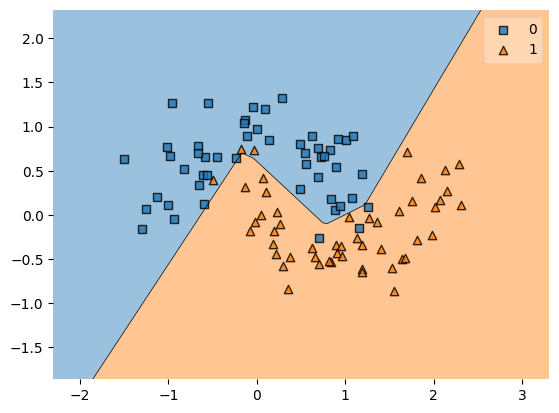

In [20]:
plot_decision_regions(X,y,model_3)
plt.xlim(-2.3)
#no overfit

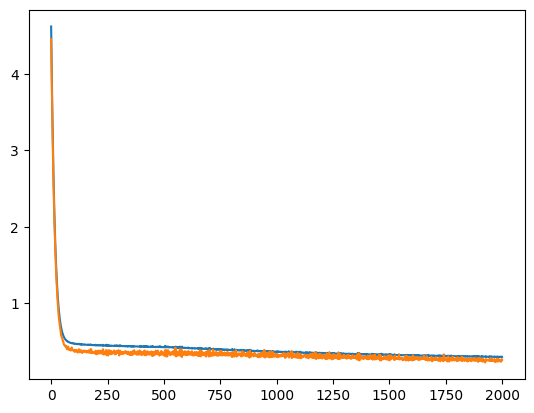

In [21]:
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
#no overfit after regularization